# M5-LBFGS vs BFGS vs L-BFGS: Andrei Test-Function Suite

Reproduces the 30-problem Andrei-collection benchmark of the paper
*"A Limited-Memory M5 Quasi-Newton Method with Armijo Damping
Globalization"* (Section 7.2-7.5): Table 1 (per-problem results),
Table 2 (aggregate summary), Table 3 (termination reasons for
non-converged runs), and Figure 1 (Dolan-More performance profiles).

The three methods reported in the paper are compared:
**BFGS**, **L-BFGS**, **M5-LBFGS**.


In [2]:
# ============================================================
# Part 1 : Imports and Global Settings
# ============================================================

import math
import time

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.grid"] = True

torch.set_default_dtype(torch.float64)
torch.manual_seed(42)
np.random.seed(42)

print("=" * 65)
print(" M5-LBFGS vs BFGS vs L-BFGS -- Andrei Test-Function Suite ")
print("=" * 65)
print("\nPyTorch Version :", torch.__version__)
print("NumPy Version   :", np.__version__)
print("Default dtype   :", torch.get_default_dtype())

# ---- Environment fingerprint, for exact reproducibility ----
# A reviewer with the SAME Python version, SAME PyTorch version, SAME
# platform, and the SAME number of CPU threads should reproduce every
# Iter. / Grad. evals / Final (f) / Final (|grad f|) / Status value in
# this notebook exactly -- there is no randomness anywhere in these
# optimizers or in the fixed problem definitions below, so the entire
# trajectory of every run is a deterministic function of these settings.
# CPU (s) is the one column NOT expected to match exactly even on an
# identical setup: wall-clock time also reflects OS scheduling, other
# running processes, and CPU thermal/frequency state, none of which are
# part of the algorithm -- that noise is exactly why converged runs are
# timed over multiple repetitions and averaged (see the runner harness),
# rather than reported from a single measurement.
import platform

print()
print("Python version     :", platform.python_version())
print("Platform           :", platform.platform())
print("CUDA available     :", torch.cuda.is_available(), "(informational only -- not used by this notebook)")
print("Default tensor device used throughout: CPU")
print("CPU threads (torch):", torch.get_num_threads())

_cpu_model = None
_total_ram = None
try:
    with open("/proc/cpuinfo") as _f:
        for _line in _f:
            if _line.lower().startswith("model name"):
                _cpu_model = _line.split(":", 1)[1].strip()
                break
except (FileNotFoundError, OSError):
    pass
if _cpu_model is None:
    _cpu_model = platform.processor() or "unavailable"

try:
    with open("/proc/meminfo") as _f:
        for _line in _f:
            if _line.startswith("MemTotal"):
                _total_ram = _line.split(":", 1)[1].strip()
                break
except (FileNotFoundError, OSError):
    pass

print("CPU model          :", _cpu_model)
print("Total RAM          :", _total_ram if _total_ram else "unavailable")


 M5-LBFGS vs BFGS vs L-BFGS -- Andrei Test-Function Suite 

PyTorch Version : 2.13.0+cpu
NumPy Version   : 2.4.6
Default dtype   : torch.float64

Python version     : 3.14.2
Platform           : Windows-10-10.0.19045-SP0
CUDA available     : False (informational only -- not used by this notebook)
Default tensor device used throughout: CPU
CPU threads (torch): 2
CPU model          : Intel64 Family 6 Model 78 Stepping 3, GenuineIntel
Total RAM          : unavailable


In [3]:
# ============================================================
# Part 2 : Optimizer Hyperparameters (problem-agnostic)
# ============================================================

MAX_ITER = 5000            # maximum outer iterations for every method
TOL = 1e-6                  # convergence tolerance on ||grad f||

MEMORY_SIZE = 20           # L-BFGS memory size (both L-BFGS and M5-LBFGS)

# ---- Strong-Wolfe constants, used ONLY by BFGS / L-BFGS ----
SW_C1 = 1e-4
SW_C2 = 0.9

# ---- Damped-Armijo constants, used ONLY by M5-LBFGS ----
# The damping parameter alpha lives INSIDE the multi-stage M5
# construction (paper Eq. 18-20), so every backtracking trial
# recomputes the whole predictor-corrector recursion at the new
# alpha -- it is NOT a classical line search on a fixed direction.
ARMIJO_C1 = 1e-4            # sufficient-decrease constant, must be < 1/2
RHO = 0.5                   # geometric backtracking reduction factor
MAX_BACKTRACK = 60          # safety cap on backtracking trials per iteration

CURVATURE_EPS = 1e-10       # epsilon_curv : L-BFGS curvature-pair acceptance threshold


TIMING_REPEATS = 10         # repeat each run this many times and average the
                              # CPU time only (iteration/eval counts are
                              # deterministic here, so a single run fixes them)

print("Optimizer Hyperparameters\n")
print(f"Maximum Iterations         : {MAX_ITER}")
print(f"Tolerance                  : {TOL}")
print(f"Memory Size                : {MEMORY_SIZE}")
print(f"Strong-Wolfe (c1, c2)      : ({SW_C1}, {SW_C2})   [BFGS / L-BFGS]")
print(f"Damped Armijo (c1, rho)    : ({ARMIJO_C1}, {RHO})   [M5-LBFGS]")
print(f"Max backtracking trials    : {MAX_BACKTRACK}")
print(f"Curvature acceptance eps   : {CURVATURE_EPS}")
print(f"Timing repeats per run     : {TIMING_REPEATS}")


Optimizer Hyperparameters

Maximum Iterations         : 5000
Tolerance                  : 1e-06
Memory Size                : 20
Strong-Wolfe (c1, c2)      : (0.0001, 0.9)   [BFGS / L-BFGS]
Damped Armijo (c1, rho)    : (0.0001, 0.5)   [M5-LBFGS]
Max backtracking trials    : 60
Curvature acceptance eps   : 1e-10
Timing repeats per run     : 10


In [4]:
# ============================================================
# Part 3 : Evaluation Counters + Wrapped Objective / Gradient
# ============================================================
# Every optimizer below calls ONLY objective(x) and gradient(x) -- never
# a problem's raw formula directly -- so that "Grad. evals" in the
# results table is an exact, comparable count across all three methods.
# For M5-LBFGS this matters even more: every backtracking TRIAL
# recomputes gradients at the trial's own intermediate points
# y_k(alpha), z_k(alpha), so the count correctly reflects the O(N_bt,k)
# trial cost from the paper's complexity analysis, not just one
# evaluation per accepted outer iteration.

COUNTERS = {"obj_evals": 0, "grad_evals": 0}

def reset_counters():
    COUNTERS["obj_evals"] = 0
    COUNTERS["grad_evals"] = 0

def make_wrapped(objective_raw):
    """Return (objective, gradient) closures wrapping a raw f(x) so that
    every call increments the shared COUNTERS dict."""

    def objective(x):
        COUNTERS["obj_evals"] += 1
        return objective_raw(x)

    def gradient(x):
        COUNTERS["grad_evals"] += 1
        f = objective_raw(x)
        g = torch.autograd.grad(outputs=f, inputs=x, create_graph=False)[0]
        return g

    return objective, gradient

print("Evaluation counters ready:", list(COUNTERS.keys()))


Evaluation counters ready: ['obj_evals', 'grad_evals']


In [5]:
# ============================================================
# Part 4 : L-BFGS Memory and Two-Loop Recursion
# ============================================================

class LBFGSMemory:
    """Stores the correction pairs (s, r) required by the L-BFGS
    two-loop recursion, together with the gamma_k initial scaling."""

    def __init__(self, memory_size=MEMORY_SIZE):
        self.memory_size = memory_size
        self.s_list = []
        self.r_list = []

    def update(self, s, r):
        self.s_list.append(s.detach().clone())
        self.r_list.append(r.detach().clone())
        if len(self.s_list) > self.memory_size:
            self.s_list.pop(0)
            self.r_list.pop(0)

    def clear(self):
        self.s_list.clear()
        self.r_list.clear()

    def size(self):
        return len(self.s_list)

    def gamma(self):
        """Initial scaling gamma_k = (s^T r) / (r^T r); returns 1.0 if
        the memory is empty (H^(0) = I)."""
        if self.size() == 0:
            return torch.tensor(1.0, dtype=torch.float64)
        s = self.s_list[-1]
        r = self.r_list[-1]
        return torch.dot(s, r) / torch.dot(r, r)


def two_loop_recursion(g, memory):
    """Compute H_k g using the standard L-BFGS two-loop recursion.
    Returns g unchanged (H_k = I) if the memory is empty.

    NOTE: this is a LINEAR map of g for a fixed memory state, which is
    exactly what lets the M5 construction below apply H_k to several
    different gradients within one damped trial while sharing the same
    (per-iteration) memory state."""
    if memory.size() == 0:
        return g.clone()

    q = g.clone()
    alpha = []
    rho = []

    for s, r in zip(reversed(memory.s_list), reversed(memory.r_list)):
        rho_i = 1.0 / torch.dot(r, s)
        alpha_i = rho_i * torch.dot(s, q)
        q = q - alpha_i * r
        rho.append(rho_i)
        alpha.append(alpha_i)

    result = memory.gamma() * q

    alpha.reverse()
    rho.reverse()

    for s, r, alpha_i, rho_i in zip(memory.s_list, memory.r_list, alpha, rho):
        beta = rho_i * torch.dot(r, result)
        result = result + s * (alpha_i - beta)

    return result

print("L-BFGS memory / two-loop recursion ready.")


L-BFGS memory / two-loop recursion ready.


In [6]:
# ============================================================
# Part 5 : Strong-Wolfe Line Search (used only by BFGS / L-BFGS)
# ============================================================
# Standard bracket + bisection-zoom strong-Wolfe search (Nocedal &
# Wright, Algorithms 3.5-3.6), made robust to non-finite trial values.
# This assumes a FIXED search direction d and only varies the scalar
# step length -- appropriate for BFGS and L-BFGS, which are genuinely
# "compute one direction, then line-search along it" methods. It is
# NOT used for M5-LBFGS (see Part 8): that method changes the
# direction itself as the damping parameter shrinks.

def _finite(v):
    return math.isfinite(v)


def strong_wolfe_line_search(x, d, f0, g0, objective, gradient,
                              c1=SW_C1, c2=SW_C2, alpha_max=1e8,
                              max_iter=50, zoom_iter=80):
    """Strong-Wolfe line search along direction d from point x.
    Returns (alpha, x_new, f_new, g_new), or None if d is not a
    descent direction (g0^T d >= 0)."""

    def trial(alpha):
        x_new = (x + alpha * d).detach().requires_grad_(True)
        phi = objective(x_new).item()
        return x_new, phi

    dphi0 = torch.dot(g0, d).item()
    if dphi0 >= 0:
        return None

    def zoom(alpha_lo, alpha_hi, phi_lo):
        alpha = alpha_lo
        for _ in range(zoom_iter):
            alpha = 0.5 * (alpha_lo + alpha_hi)
            x_new, phi = trial(alpha)
            if (not _finite(phi)) or phi > f0 + c1 * alpha * dphi0 or phi >= phi_lo:
                alpha_hi = alpha
            else:
                g_new = gradient(x_new)
                dphi = torch.dot(g_new, d).item()
                if abs(dphi) <= -c2 * dphi0:
                    return alpha, x_new, phi, g_new
                if dphi * (alpha_hi - alpha_lo) >= 0:
                    alpha_hi = alpha_lo
                alpha_lo = alpha
                phi_lo = phi
            if alpha_hi - alpha_lo < 1e-300:
                break
        x_new, phi = trial(alpha_lo)
        g_new = gradient(x_new)
        return alpha_lo, x_new, phi, g_new

    alpha_prev = 0.0
    phi_prev = f0
    alpha = 1.0

    for i in range(max_iter):
        x_new, phi = trial(alpha)
        if (not _finite(phi)) or phi > f0 + c1 * alpha * dphi0 or (i > 0 and phi >= phi_prev):
            return zoom(alpha_prev, alpha, phi_prev)
        g_new = gradient(x_new)
        dphi = torch.dot(g_new, d).item()
        if abs(dphi) <= -c2 * dphi0:
            return alpha, x_new, phi, g_new
        if dphi >= 0:
            return zoom(alpha, alpha_prev, phi)
        alpha_prev, phi_prev = alpha, phi
        alpha = min(2.0 * alpha, alpha_max)

    x_new, phi = trial(alpha)
    g_new = gradient(x_new)
    return alpha, x_new, phi, g_new


def accept_direction(x, d, g, f0, objective, gradient, c1=SW_C1, c2=SW_C2, min_alpha=1e-14):
    """Attempt the strong-Wolfe line search along d. Returns None if d
    is not a descent direction, or if the search degenerates."""
    if not torch.isfinite(d).all():
        return None
    if torch.dot(g, d).item() >= 0:
        return None

    result = strong_wolfe_line_search(x, d, f0, g, objective, gradient, c1, c2)
    if result is None:
        return None

    alpha, x_new, f_new, g_new = result
    if alpha < min_alpha or not _finite(f_new):
        return None

    return alpha, x_new, f_new, g_new

print("Strong-Wolfe line search ready.")


Strong-Wolfe line search ready.


In [7]:
# ============================================================
# Part 6 : Classical BFGS (dense, strong-Wolfe globalized)
# ============================================================

def bfgs_sw(x0, objective, gradient, max_iter=MAX_ITER, tol=TOL, c1=SW_C1, c2=SW_C2):
    x = x0.clone().detach().requires_grad_(True)
    n = x.numel()

    H = torch.eye(n, dtype=torch.float64)
    I = torch.eye(n, dtype=torch.float64)

    g = gradient(x)

    history = []
    converged = False
    reason = "Maximum iterations reached"
    k = 0

    for k in range(max_iter):
        f = objective(x).item()
        gn = torch.norm(g).item()
        history.append({"Iteration": k, "Objective": f, "Gradient Norm": gn})

        if gn < tol:
            converged = True
            reason = "Gradient tolerance reached"
            break

        d = -(H @ g)
        result = accept_direction(x, d, g, f, objective, gradient, c1, c2)
        if result is None:
            result = accept_direction(x, -g, g, f, objective, gradient, c1, c2)
        if result is None:
            reason = "Line search failed (not descent)"
            break

        alpha, x_new, f_new, g_new = result
        s = x_new.detach() - x.detach()
        y = g_new.detach() - g.detach()
        sy = torch.dot(s, y).item()

        if sy > CURVATURE_EPS:
            rho = 1.0 / sy
            H = (I - rho * torch.outer(s, y)) @ H @ (I - rho * torch.outer(y, s)) \
                + rho * torch.outer(s, s)

        x, g = x_new, g_new

    return x, history, converged, reason, k

print("BFGS (strong-Wolfe) ready.")


BFGS (strong-Wolfe) ready.


In [8]:
# ============================================================
# Part 7 : Classical L-BFGS (strong-Wolfe globalized)
# ============================================================

def lbfgs_sw(x0, objective, gradient, memory_size=MEMORY_SIZE, max_iter=MAX_ITER,
             tol=TOL, c1=SW_C1, c2=SW_C2):
    x = x0.clone().detach().requires_grad_(True)
    memory = LBFGSMemory(memory_size)

    g = gradient(x)

    history = []
    converged = False
    reason = "Maximum iterations reached"
    k = 0

    for k in range(max_iter):
        f = objective(x).item()
        gn = torch.norm(g).item()
        history.append({"Iteration": k, "Objective": f, "Gradient Norm": gn})

        if gn < tol:
            converged = True
            reason = "Gradient tolerance reached"
            break

        Hg = two_loop_recursion(g, memory)
        d = -Hg

        result = accept_direction(x, d, g, f, objective, gradient, c1, c2)
        if result is None:
            result = accept_direction(x, -g, g, f, objective, gradient, c1, c2)
        if result is None:
            reason = "Line search failed (not descent)"
            break

        alpha, x_new, f_new, g_new = result
        s = x_new.detach() - x.detach()
        r = g_new.detach() - g.detach()

        if torch.dot(s, r).item() > CURVATURE_EPS:
            memory.update(s, r)

        x, g = x_new, g_new

    return x, history, converged, reason, k

print("L-BFGS (strong-Wolfe) ready.")


L-BFGS (strong-Wolfe) ready.


In [9]:
# ============================================================
# Part 8 : M5-LBFGS -- Damped Armijo Backtracking Core + Construction
# ============================================================
# damped_armijo_backtrack implements Definition 4.7 / Algorithm 2: the
# damping parameter alpha is fed to construct_fn(x, g, memory, alpha),
# which RECOMPUTES THE ENTIRE multi-stage predictor-corrector
# recursion at that alpha (Eq. 18-20) -- it is not a scalar multiplier
# applied to one fixed pre-computed vector. Trial parameters are
# alpha_j = rho^j, j = 0, 1, 2, ..., and the accepted alpha is the
# first for which both the descent condition and the Armijo
# sufficient-decrease condition hold.

def m5_displacement(x, g, memory, alpha, gradient):
    """Complete damped M5 construction, Eq. (18)-(20), at parameter alpha:

        y_k(alpha) = x_k - alpha * H_k g_k
        z_k(alpha) = y_k(alpha) - 5 alpha * H_k grad f(y_k(alpha))
        xhat_{k+1}(alpha) = z_k(alpha)
                             - (alpha/5) * H_k[-16 grad f(y_k(alpha)) + grad f(z_k(alpha))]
        d_k(alpha) = xhat_{k+1}(alpha) - x_k

    At alpha = 1 this reduces exactly to the raw construction (7)-(10).
    Every call recomputes both intermediate gradients, so this
    function -- not a single cached direction -- is what backtracking
    calls once per trial."""
    Hg = two_loop_recursion(g, memory)
    y = (x.detach() - alpha * Hg).requires_grad_(True)
    gy = gradient(y)

    Hgy = two_loop_recursion(gy, memory)
    z = (y.detach() - 5.0 * alpha * Hgy).requires_grad_(True)
    gz = gradient(z)

    Hgz = two_loop_recursion(gz, memory)
    x_hat = z.detach() - (alpha / 5.0) * (-16.0 * Hgy + Hgz)

    return x_hat - x.detach()


def damped_armijo_backtrack(x, g, f0, memory, construct_fn, objective,
                             c1=ARMIJO_C1, rho=RHO, max_trials=MAX_BACKTRACK):
    alpha = 1.0
    for _ in range(max_trials):
        d = construct_fn(x, g, memory, alpha)
        if torch.isfinite(d).all():
            gTd = torch.dot(g, d).item()
            if gTd < 0:
                x_new = (x.detach() + d).detach().requires_grad_(True)
                f_new = objective(x_new).item()
                if math.isfinite(f_new) and f_new <= f0 + c1 * gTd:
                    return alpha, d, x_new, f_new
        alpha *= rho
    return None


print("M5 damped Armijo core ready.")


M5 damped Armijo core ready.


In [10]:
# ============================================================
# Part 9 : M5-LBFGS -- Full Iteration
# ============================================================
# Implements Algorithm 2 literally: if damped_armijo_backtrack exhausts
# MAX_BACKTRACK trials without an acceptance -- which Theorem 4.9 proves
# will not happen at a nonstationary point under the paper's stated
# assumptions -- the run terminates with reason =
# "Damped Armijo backtracking failed (Algorithm 2)" rather than
# substituting a different step. No fallback / safety-net code path.

def m5_lbfgs(x0, objective, gradient, memory_size=MEMORY_SIZE, max_iter=MAX_ITER,
             tol=TOL, c1=ARMIJO_C1, rho=RHO, max_backtrack=MAX_BACKTRACK,
             curvature_eps=CURVATURE_EPS):

    x = x0.clone().detach().requires_grad_(True)
    memory = LBFGSMemory(memory_size)

    g = gradient(x)

    history = []
    converged = False
    reason = "Maximum iterations reached"
    k = 0

    def construct_fn(xx, gg, mem, a):
        return m5_displacement(xx, gg, mem, a, gradient)

    for k in range(max_iter):
        f = objective(x).item()
        gn = torch.norm(g).item()
        history.append({"Iteration": k, "Objective": f, "Gradient Norm": gn})

        if gn < tol:
            converged = True
            reason = "Gradient tolerance reached"
            break

        result = damped_armijo_backtrack(
            x, g, f, memory, construct_fn, objective, c1=c1, rho=rho, max_trials=max_backtrack)

        if result is None:
            reason = "Damped Armijo backtracking failed (Algorithm 2)"
            break

        alpha, d, x_new, f_new = result
        g_new = gradient(x_new)

        s = x_new.detach() - x.detach()
        r = g_new.detach() - g.detach()

        if torch.dot(s, r).item() > curvature_eps:
            memory.update(s, r)

        x, g = x_new, g_new

    return x, history, converged, reason, k

print("M5-LBFGS (damped, Algorithm 2) ready.")


M5-LBFGS (damped, Algorithm 2) ready.


## Andrei-style Test Function Suite (30 problems)

Every problem below is written generically in `x` (a 1-D `torch.Tensor`
with `requires_grad=True`) so PyTorch autograd supplies exact
gradients -- no analytic gradient needs to be hand-derived or
hand-checked. Each entry in the `PROBLEMS` registry carries a `name`,
dimension `n`, standard starting point `x0`, and the raw objective `f`.

Source: N. Andrei, "An unconstrained optimization test functions
collection", Advanced Modeling and Optimization 10(1), 147-161 (2008).

**Dimension.** All 30 problems are instantiated at `N = 500` (the
paper's dimension for Table 1-3). `N` must be even (needed by every
extended/pair problem below); it need not be a multiple of 3 -- DIXMAANA
uses `n // 3` internally via floor division.


In [11]:
N = 500  # common dimension for every problem in the suite (see markdown above)

PROBLEMS = []

def register(name, n, x0_vals, f_min=None):
    """Decorator: adds (name, n, x0, f, f_min) to the PROBLEMS registry."""
    def deco(fn):
        PROBLEMS.append({
            "name": name,
            "n": n,
            "x0": torch.tensor(x0_vals, dtype=torch.float64, requires_grad=True),
            "f": fn,
            "f_min": f_min,
        })
        return fn
    return deco


# 1. Almost Perturbed Quadratic
@register("Almost Perturbed Quadratic", N, [1.0] * N)
def f_almost_perturbed_quadratic(x):
    n = x.numel()
    idx = torch.arange(1, n + 1, dtype=torch.float64)
    return torch.sum(idx * x ** 2) + 0.25 * (x[0] + x[-1]) ** 2


# 2. ARWHEAD
@register("ARWHEAD", N, [1.0] * N, f_min=0.0)
def f_arwhead(x):
    xi = x[:-1]
    xn = x[-1]
    return torch.sum((xi ** 2 + xn ** 2) ** 2 - 4.0 * xi + 3.0)


# 3. BIGGSB1 (generalized / chained form)
@register("BIGGSB1", N, [0.0] * N, f_min=0.0)
def f_biggsb1(x):
    term = (x[0] - 1.0) ** 2 + (x[-1] - 1.0) ** 2
    term = term + torch.sum((x[1:] - x[:-1] ** 2) ** 2)
    return term


# 4. Diagonal 1
@register("Diagonal 1", N, [1.0] * N)
def f_diagonal1(x):
    n = x.numel()
    idx = torch.arange(1, n + 1, dtype=torch.float64)
    return torch.sum(torch.exp(x) - idx * x)


# 5. Diagonal 2
@register("Diagonal 2", N, [1.0] * N)
def f_diagonal2(x):
    n = x.numel()
    idx = torch.arange(1, n + 1, dtype=torch.float64)
    return torch.sum((torch.exp(x) - idx * x) / idx)


# 6. Diagonal 3
@register("Diagonal 3", N, [1.0] * N)
def f_diagonal3(x):
    n = x.numel()
    idx = torch.arange(1, n + 1, dtype=torch.float64)
    return torch.sum(torch.exp(x) - idx * torch.sin(x))


# 7. Diagonal 7
@register("Diagonal 7", N, [1.0] * N)
def f_diagonal7(x):
    return torch.sum(torch.exp(x) - x)


# 8. Diagonal 9
@register("Diagonal 9", N, [1.0] * N)
def f_diagonal9(x):
    n = x.numel()
    idx = torch.arange(1, n + 1, dtype=torch.float64)
    return torch.sum(idx * (torch.exp(x) - x))


# 9. DIXMAANA (k1=k2=k3=k4=0 member of the DIXMAANA-DIXMAANL family)
@register("DIXMAANA", N, [2.0] * N, f_min=1.0)
def f_dixmaana(x):
    n = x.numel()
    m = n // 3
    alpha, beta, gamma, delta = 1.0, 0.125, 0.125, 0.125
    i = torch.arange(1, n + 1, dtype=torch.float64)
    term1 = 1.0 + torch.sum(alpha * x ** 2 * (i / n))
    term2 = torch.sum(beta * (x[:-1] ** 2) * (x[1:] + x[:-1] ** 2) ** 2)
    i3 = torch.arange(1, 2 * m + 1, dtype=torch.float64)
    term3 = torch.sum(gamma * (x[:2 * m] ** 2) * (x[m:3 * m] ** 4) * (i3 / n))
    i4 = torch.arange(1, m + 1, dtype=torch.float64)
    term4 = torch.sum(delta * x[:m] * x[2 * m:3 * m] * (i4 / n))
    return term1 + term2 + term3 + term4


# 10. DQDRTIC
@register("DQDRTIC", N, [3.0] * N, f_min=0.0)
def f_dqdrtic(x):
    return torch.sum(x[:-2] ** 2) + 100.0 * torch.sum(x[1:-1] ** 2 + x[2:] ** 2)


# 11. EDENSCH
@register("EDENSCH", N, [0.0] * N)
def f_edensch(x):
    xi = x[:-1]
    xi1 = x[1:]
    return 16.0 + torch.sum((xi - 2.0) ** 4 + (xi * xi1 - 2.0 * xi1) ** 2 + (xi1 + 1.0) ** 2)


# 12. ENGVAL1
@register("ENGVAL1", N, [2.0] * N)
def f_engval1(x):
    xi = x[:-1]
    xi1 = x[1:]
    return torch.sum((xi ** 2 + xi1 ** 2) ** 2 - 4.0 * xi + 3.0)


# 13. Extended Beale
@register("Extended Beale", N, [1.0, 0.8] * (N // 2), f_min=0.0)
def f_extended_beale(x):
    x1 = x[0::2]
    x2 = x[1::2]
    t1 = 1.5 - x1 * (1.0 - x2)
    t2 = 2.25 - x1 * (1.0 - x2 ** 2)
    t3 = 2.625 - x1 * (1.0 - x2 ** 3)
    return torch.sum(t1 ** 2 + t2 ** 2 + t3 ** 2)


# 14. Extended DENSCHNB
@register("Extended DENSCHNB", N, [1.0, 1.0] * (N // 2), f_min=0.0)
def f_extended_denschnb(x):
    x1 = x[0::2]
    x2 = x[1::2]
    return torch.sum((x1 - 2.0) ** 2 + ((x1 - 2.0) * x2) ** 2 + (x2 + 1.0) ** 2)


# 15. Extended Freudenstein and Roth
@register("Extended Freudenstein and Roth", N, [0.5, -2.0] * (N // 2))
def f_extended_freud_roth(x):
    x1 = x[0::2]
    x2 = x[1::2]
    t1 = -13.0 + x1 + ((5.0 - x2) * x2 - 2.0) * x2
    t2 = -29.0 + x1 + ((x2 + 1.0) * x2 - 14.0) * x2
    return torch.sum(t1 ** 2 + t2 ** 2)


# 16. Extended PSC1
@register("Extended PSC1", N, [3.0, 0.1] * (N // 2))
def f_extended_psc1(x):
    x1 = x[0::2]
    x2 = x[1::2]
    return torch.sum((x1 ** 2 + x2 ** 2 + x1 * x2) ** 2 + torch.sin(x1) ** 2 + torch.cos(x2) ** 2)


# 17. Extended Tridiagonal 1
@register("Extended Tridiagonal 1", N, [2.0] * N, f_min=0.0)
def f_extended_tridiagonal1(x):
    xi = x[:-1]
    xi1 = x[1:]
    return torch.sum((xi + xi1 - 3.0) ** 2 + (xi - xi1 + 1.0) ** 4)


# 18. Extended Tridiagonal 2
@register("Extended Tridiagonal 2", N, [1.0] * N)
def f_extended_tridiagonal2(x):
    xi = x[:-1]
    xi1 = x[1:]
    return torch.sum(0.1 * (xi ** 2 + xi1 ** 2) + (xi * xi1 - 1.0) ** 2)


# 19. Fletcher
@register("Fletcher", N, [-1.0] * N, f_min=0.0)
def f_fletcher(x):
    xi = x[:-1]
    xi1 = x[1:]
    return torch.sum(100.0 * (xi1 - xi + 1.0 - xi ** 2) ** 2 + (1.0 - xi) ** 2)


# 20. Generalized PSC1
@register("Generalized PSC1", N, [3.0] * N)
def f_generalized_psc1(x):
    xi = x[:-1]
    xi1 = x[1:]
    return torch.sum((xi ** 2 + xi1 ** 2 + xi * xi1) ** 2 + torch.sin(xi) ** 2 + torch.cos(xi1) ** 2)


# 21. Hager
@register("Hager", N, [1.0] * N)
def f_hager(x):
    n = x.numel()
    idx = torch.arange(1, n + 1, dtype=torch.float64)
    return torch.sum(torch.exp(x) - torch.sqrt(idx) * x)


# 22. HIMMELH (extended, pairwise HIMMELBH-type block)
@register("HIMMELH", N, [0.0] * N)
def f_himmelh(x):
    x1 = x[0::2]
    x2 = x[1::2]
    return torch.sum(-3.0 * x1 + 2.0 * x2 + 2.0 * x1 ** 2 + 2.0 * x1 * x2 + x2 ** 2)


# 23. Partial Perturbed Quadratic
@register("Partial Perturbed Quadratic", N, [1.0] * N)
def f_partial_perturbed_quadratic(x):
    n = x.numel()
    idx = torch.arange(1, n + 1, dtype=torch.float64)
    return torch.sum(idx * x ** 2) + 0.01 * torch.sum(x[:-1] * x[1:])


# 24. Perturbed Quadratic Diagonal
@register("Perturbed Quadratic Diagonal", N, [1.0] * N)
def f_perturbed_quadratic_diagonal(x):
    n = x.numel()
    idx = torch.arange(1, n + 1, dtype=torch.float64)
    return torch.sum(idx * x ** 2) + 0.5 * torch.sum(x) ** 2


# 25. Perturbed Tridiagonal Quadratic
@register("Perturbed Tridiagonal Quadratic", N, [1.0] * N)
def f_perturbed_tridiagonal_quadratic(x):
    n = x.numel()
    idx = torch.arange(1, n + 1, dtype=torch.float64)
    diag = torch.sum(idx * x ** 2)
    tri = torch.sum((x[:-1] - x[1:]) ** 2)
    return diag + tri


# 26. Quadratic QF1
@register("Quadratic QF1", N, [1.0] * N)
def f_quadratic_qf1(x):
    n = x.numel()
    idx = torch.arange(1, n + 1, dtype=torch.float64)
    return 0.5 * torch.sum(idx * x ** 2) - x[-1]


# 27. Quadratic QF2
@register("Quadratic QF2", N, [0.5] * N)
def f_quadratic_qf2(x):
    n = x.numel()
    idx = torch.arange(1, n + 1, dtype=torch.float64)
    return 0.5 * torch.sum(idx * (x - 1.0) ** 2) - x[-1]


# 28. Raydan 1
@register("Raydan 1", N, [1.0] * N)
def f_raydan1(x):
    n = x.numel()
    idx = torch.arange(1, n + 1, dtype=torch.float64)
    return torch.sum((idx / 10.0) * (torch.exp(x) - x))


# 29. Raydan 2
@register("Raydan 2", N, [1.0] * N)
def f_raydan2(x):
    return torch.sum(torch.exp(x) - x)


# 30. Tridia
@register("Tridia", N, [1.0] * N, f_min=0.0)
def f_tridia(x):
    n = x.numel()
    idx = torch.arange(2, n + 1, dtype=torch.float64)
    return (x[0] - 1.0) ** 2 + torch.sum(idx * (2.0 * x[1:] - x[:-1]) ** 2)

print(f"Registered {len(PROBLEMS)} problems at N = {N}.\n")
check_df = pd.DataFrame([
    {"Problem": p["name"], "n": p["n"], "f(x0)": p["f"](p["x0"]).item(),
     "known f_min": p["f_min"] if p["f_min"] is not None else "-"}
    for p in PROBLEMS
])
pd.set_option("display.width", 160)
print(check_df.to_string(index=False))


Registered 30 problems at N = 500.

                        Problem   n          f(x0) known f_min
     Almost Perturbed Quadratic 500  125251.000000           -
                        ARWHEAD 500    1497.000000         0.0
                        BIGGSB1 500       2.000000         0.0
                     Diagonal 1 500 -123890.859086           -
                     Diagonal 2 500    -481.535192           -
                     Diagonal 3 500 -104035.099933           -
                     Diagonal 7 500     859.140914           -
                     Diagonal 9 500  215214.799014           -
                       DIXMAANA 500   10883.309000         1.0
                        DQDRTIC 500  900882.000000         0.0
                        EDENSCH 500    8499.000000           -
                        ENGVAL1 500   29441.000000           -
                 Extended Beale 500    2457.217250         0.0
              Extended DENSCHNB 500    1500.000000         0.0
 Extended Freudenst

In [12]:
# ============================================================
# Part 11 : Runner Harness (single problem, single method)
# ============================================================

def run_method(name, fn, problem, **kwargs):
    """Run one optimizer on one problem and return a results row plus
    its convergence history.

    CPU-timing strategy: the first (counting) run is always timed. If
    that run CONVERGED, TIMING_REPEATS - 1 additional timed repeats are
    added and averaged in, for a stable CPU-time estimate (iteration /
    evaluation counts are deterministic, so a single run already fixes
    those). If the run did NOT converge -- i.e. it burned through the
    full max_iter budget -- it is timed ONCE only: repeating an
    already-at-the-iteration-cap run several more times just multiplies
    the most expensive case in the whole suite for very little
    additional precision (its cost is dominated by a fixed iteration
    count, not by run-to-run noise), so it is not worth the wall-clock
    cost here."""
    x0 = problem["x0"]
    objective, gradient = make_wrapped(problem["f"])

    reset_counters()
    t0 = time.time()
    out = fn(x0, objective, gradient, **kwargs)
    t1 = time.time()
    x_final, history = out[0], out[1]
    converged, reason, k = out[2], out[3], out[4]
    grad_evals = COUNTERS["grad_evals"]

    times = [t1 - t0]
    if converged:
        for _ in range(TIMING_REPEATS - 1):
            reset_counters()
            t0 = time.time()
            fn(x0, objective, gradient, **kwargs)
            t1 = time.time()
            times.append(t1 - t0)
    cpu_time = float(np.mean(times))

    last = history[-1]

    row = {
        "Problem": problem["name"],
        "n": problem["n"],
        "Method": name,
        "Iter.": len(history) - 1,
        "CPU (s)": round(cpu_time, 4),
        "Grad. evals": grad_evals,
        "Final (f)": last["Objective"],
        "Final (|grad f|)": last["Gradient Norm"],
        "Converged": converged,
        "Termination": reason,
    }
    return row, history, x_final

print("Runner harness ready.")


Runner harness ready.


In [13]:
# ============================================================
# Part 12 : Run BFGS / L-BFGS / M5-LBFGS on All 30 Problems
# ============================================================

METHODS = [
    ("BFGS", bfgs_sw),
    ("L-BFGS", lbfgs_sw),
    ("M5-LBFGS", m5_lbfgs),
]

MASTER_RESULTS = []
HISTORIES = {}   # HISTORIES[(problem_name, method_name)] -> history list

print("=" * 65)
print(f" Running {len(METHODS)} methods on {len(PROBLEMS)} Andrei-style problems ")
print("=" * 65)

for problem in PROBLEMS:
    for method_name, fn in METHODS:
        row, history, x_final = run_method(method_name, fn, problem)
        MASTER_RESULTS.append(row)
        HISTORIES[(problem["name"], method_name)] = history
    print(f"  done: {problem['name']}")

print("\nAll runs complete. Total result rows:", len(MASTER_RESULTS))


 Running 3 methods on 30 Andrei-style problems 
  done: Almost Perturbed Quadratic
  done: ARWHEAD
  done: BIGGSB1
  done: Diagonal 1
  done: Diagonal 2
  done: Diagonal 3
  done: Diagonal 7
  done: Diagonal 9
  done: DIXMAANA
  done: DQDRTIC
  done: EDENSCH
  done: ENGVAL1
  done: Extended Beale
  done: Extended DENSCHNB
  done: Extended Freudenstein and Roth
  done: Extended PSC1
  done: Extended Tridiagonal 1
  done: Extended Tridiagonal 2
  done: Fletcher
  done: Generalized PSC1
  done: Hager
  done: HIMMELH
  done: Partial Perturbed Quadratic
  done: Perturbed Quadratic Diagonal
  done: Perturbed Tridiagonal Quadratic
  done: Quadratic QF1
  done: Quadratic QF2
  done: Raydan 1
  done: Raydan 2
  done: Tridia

All runs complete. Total result rows: 90


In [14]:
# ============================================================
# Part 13 : Master Results Table (grouped, paper-Table-1 style)
# ============================================================

def format_grouped_table(rows):
    df = pd.DataFrame(rows)
    display_cols = [
        "Problem", "n", "Method", "Iter.", "CPU (s)",
        "Grad. evals", "Final (f)", "Final (|grad f|)", "Converged"
    ]
    df_display = df[display_cols].copy()
    df_display["n"] = df_display["n"].astype(str)
    df_display["Final (f)"] = df_display["Final (f)"].map(lambda v: f"{v:.6e}")
    df_display["Final (|grad f|)"] = df_display["Final (|grad f|)"].map(lambda v: f"{v:.6e}")
    df_display["Status"] = np.where(df["Converged"], "C", "NC")
    df_display = df_display.drop(columns=["Converged"])

    mask = df_display["Problem"].duplicated()
    df_display.loc[mask, "Problem"] = ""
    df_display.loc[mask, "n"] = ""
    return df_display

master_df = pd.DataFrame(MASTER_RESULTS)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)

print("=" * 65)
print(" Master Results Table -- all 30 problems x 3 methods (Table 1) ")
print("=" * 65)
print()
print(format_grouped_table(MASTER_RESULTS).to_string(index=False))

print("\nTermination reasons for any non-converged run:")
for r in MASTER_RESULTS:
    if not r["Converged"]:
        print(f"  {r['Problem']:35s} {r['Method']:<10s}: {r['Termination']}")


 Master Results Table -- all 30 problems x 3 methods (Table 1) 

                        Problem   n   Method  Iter.  CPU (s)  Grad. evals     Final (f) Final (|grad f|) Status
     Almost Perturbed Quadratic 500     BFGS   2519  18.1328         2754  9.479843e-16     9.992471e-07      C
                                      L-BFGS    668   2.1381          727  1.365338e-13     9.160420e-07      C
                                    M5-LBFGS    287   2.8769          954  1.280190e-13     9.975525e-07      C
                        ARWHEAD 500     BFGS     17   0.3055           21  0.000000e+00     1.908821e-05     NC
                                      L-BFGS     10   0.0762           17  0.000000e+00     1.521453e-05     NC
                                    M5-LBFGS      8   0.0516           49  0.000000e+00     7.555366e-09      C
                        BIGGSB1 500     BFGS    469   8.1820          526  5.000000e-01     7.348013e-07      C
                                      L

In [15]:
# ============================================================
# Part 14 : CSV Export (reproducibility / supplementary material)
# ============================================================

csv_path = "andrei_suite_results.csv"
master_df.to_csv(csv_path, index=False)
print(f"Saved full results table to: {csv_path}")
master_df.head()


Saved full results table to: andrei_suite_results.csv


,Problem,n,Method,Iter.,CPU (s),Grad. evals,Final (f),Final (|grad f|),Converged,Termination
0,Almost Perturbed Quadratic,500,BFGS,2519,18.1328,2754,9.479843e-16,9.992471e-07,True,Gradient tolerance reached
1,Almost Perturbed Quadratic,500,L-BFGS,668,2.1381,727,1.365338e-13,9.160420e-07,True,Gradient tolerance reached
2,Almost Perturbed Quadratic,500,M5-LBFGS,287,2.8769,954,1.280190e-13,9.975525e-07,True,Gradient tolerance reached
3,ARWHEAD,500,BFGS,17,0.3055,21,0.000000e+00,1.908821e-05,False,Line search failed (not descent)
4,ARWHEAD,500,L-BFGS,10,0.0762,17,0.000000e+00,1.521453e-05,False,Line search failed (not descent)


In [16]:
# ============================================================
# Part 15 : Aggregate Summary Statistics (Table 2)
# ============================================================

summary_rows = []
for method_name, _ in METHODS:
    sub = master_df[master_df["Method"] == method_name]
    cpu_conv = sub.loc[sub["Converged"], "CPU (s)"]
    summary_rows.append({
        "Method": method_name,
        "Problems converged": int(sub["Converged"].sum()),
        "Problems total": len(sub),
        "Convergence rate": f"{100.0 * sub['Converged'].mean():.1f}%",
        "Mean iterations (converged)": round(sub.loc[sub["Converged"], "Iter."].mean(), 1),
        "Median iterations (converged)": round(sub.loc[sub["Converged"], "Iter."].median(), 1),
        "Mean grad. evals (converged)": round(sub.loc[sub["Converged"], "Grad. evals"].mean(), 1),
        "Mean CPU (s) (converged)": round(cpu_conv.mean(), 4),
        # CPU time is heavily right-skewed by a small number of hard problems
        # (the mean is dragged up by these); the median and quartiles below
        # give a distribution-robust picture that the mean alone cannot.
        "Median CPU (s) (converged)": round(cpu_conv.median(), 4),
        "Q1 CPU (s) (converged)": round(cpu_conv.quantile(0.25), 4),
        "Q3 CPU (s) (converged)": round(cpu_conv.quantile(0.75), 4),
    })

summary_df = pd.DataFrame(summary_rows)
print("Aggregate summary across all 30 problems (Table 2)\n")
print(summary_df.to_string(index=False))
summary_df.to_csv("table2_aggregate_summary.csv", index=False)

# Head-to-head: M5-LBFGS vs each baseline, on problems where BOTH converged
print("\nHead-to-head comparisons (problems where both methods converged)\n")

pivot_iter = master_df.pivot(index="Problem", columns="Method", values="Iter.")
pivot_grad = master_df.pivot(index="Problem", columns="Method", values="Grad. evals")
pivot_conv = master_df.pivot(index="Problem", columns="Method", values="Converged")

for baseline in ["BFGS", "L-BFGS"]:
    both_converged = pivot_conv["M5-LBFGS"] & pivot_conv[baseline]
    n_both = int(both_converged.sum())

    iter_m5 = pivot_iter.loc[both_converged, "M5-LBFGS"]
    iter_bl = pivot_iter.loc[both_converged, baseline]
    wins = int((iter_m5 < iter_bl).sum())
    ties = int((iter_m5 == iter_bl).sum())
    losses = int((iter_m5 > iter_bl).sum())
    pct_reduction = 100.0 * (1.0 - (iter_m5 / iter_bl)).mean()

    grad_m5 = pivot_grad.loc[both_converged, "M5-LBFGS"]
    grad_bl = pivot_grad.loc[both_converged, baseline]
    grad_pct = 100.0 * (1.0 - (grad_m5 / grad_bl)).mean()

    print(f"M5-LBFGS vs {baseline}  (n = {n_both} problems where both converged)")
    print(f"  Iterations   : {wins} wins / {ties} ties / {losses} losses "
          f"  (avg iteration change: {pct_reduction:+.1f}%, positive = M5-LBFGS uses fewer)")
    print(f"  Grad. evals  : avg change {grad_pct:+.1f}% "
          f"(positive = M5-LBFGS uses fewer, negative = M5-LBFGS uses more)")
    print()


Aggregate summary across all 30 problems (Table 2)

  Method  Problems converged  Problems total Convergence rate  Mean iterations (converged)  Median iterations (converged)  Mean grad. evals (converged)  Mean CPU (s) (converged)  Median CPU (s) (converged)  Q1 CPU (s) (converged)  Q3 CPU (s) (converged)
    BFGS                  20              30            66.7%                        819.1                          209.0                         894.6                    6.7944                      1.5174                  0.3414                 13.0544
  L-BFGS                  23              30            76.7%                        332.2                           26.0                         443.1                    1.5234                      0.0673                  0.0326                  1.7852
M5-LBFGS                  29              30            96.7%                        140.5                           25.0                         776.6                    2.3731         

## Dolan-More Performance Profiles

Dolan, E.D., More, J.J., *Benchmarking optimization software with
performance profiles*, Math. Programming 91(2), 2002, 201-213.

For each problem $p$ and solver $s$, let $t_{p,s}$ be the performance
metric (iterations, gradient evaluations, or CPU time). A solver that
failed to converge on $p$ is assigned $t_{p,s} = \infty$. The
performance ratio is $r_{p,s} = t_{p,s} / \min_s t_{p,s}$, and the
profile is

$$\rho_s(\tau) = \frac{1}{|\mathcal P|}\,\bigl|\{p \in \mathcal P : r_{p,s} \le \tau\}\bigr|.$$


In [17]:
# ============================================================
# Part 16 : Dolan-More Performance Profile Computation
# ============================================================

def dolan_more_profile(master_df, metric_col, methods, require_converged=True):
    """Compute Dolan-More performance profiles for one metric.
    Returns dict: method_name -> (taus, rho) suitable for a step plot."""
    problems = master_df["Problem"].unique().tolist()
    T = np.full((len(problems), len(methods)), np.inf)

    for i, p in enumerate(problems):
        for j, s in enumerate(methods):
            row = master_df[(master_df["Problem"] == p) & (master_df["Method"] == s)]
            if len(row) == 0:
                continue
            row = row.iloc[0]
            if require_converged and not row["Converged"]:
                continue
            T[i, j] = row[metric_col]

    best = np.min(T, axis=1, keepdims=True)
    best[best == 0] = np.finfo(float).eps
    R = T / best

    finite_vals = R[np.isfinite(R)]
    taus = np.unique(finite_vals)
    taus = np.concatenate([[1.0], taus, [taus.max() * 1.0]]) if len(taus) else np.array([1.0])
    taus = np.sort(np.unique(taus))
    taus_plot = np.sort(np.unique(np.concatenate([taus, taus * (1 + 1e-9)])))

    curves = {}
    for j, s in enumerate(methods):
        rho = [(R[:, j] <= t).sum() / len(problems) for t in taus_plot]
        curves[s] = (taus_plot, np.array(rho))

    return curves


def plot_performance_profile(curves, title, xlabel=r"Performance ratio $\tau$"):
    plt.figure(figsize=(8, 6))
    markers = {"BFGS": "o", "L-BFGS": "s", "M5-LBFGS": "^"}
    for method_name, (taus, rho) in curves.items():
        plt.step(taus, rho, where="post", linewidth=2,
                  marker=markers.get(method_name, "o"), markersize=4,
                  markevery=max(1, len(taus) // 15), label=method_name)
    plt.xlabel(xlabel)
    plt.ylabel(r"$\rho_s(\tau)$")
    plt.title(title)
    plt.ylim(-0.02, 1.05)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

print("Dolan-More performance profile utilities ready.")


Dolan-More performance profile utilities ready.


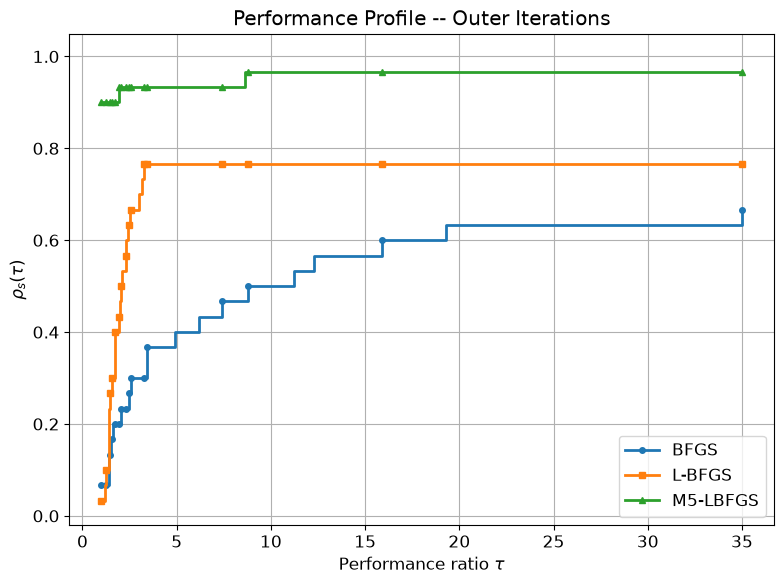

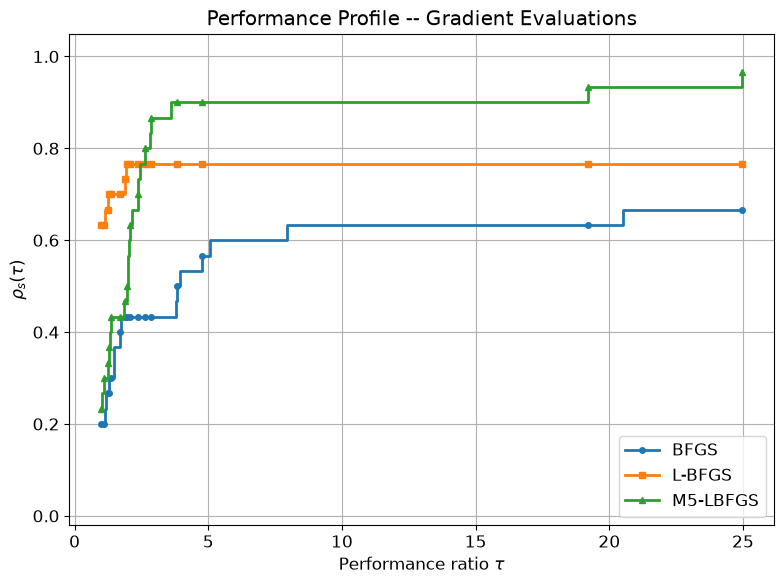

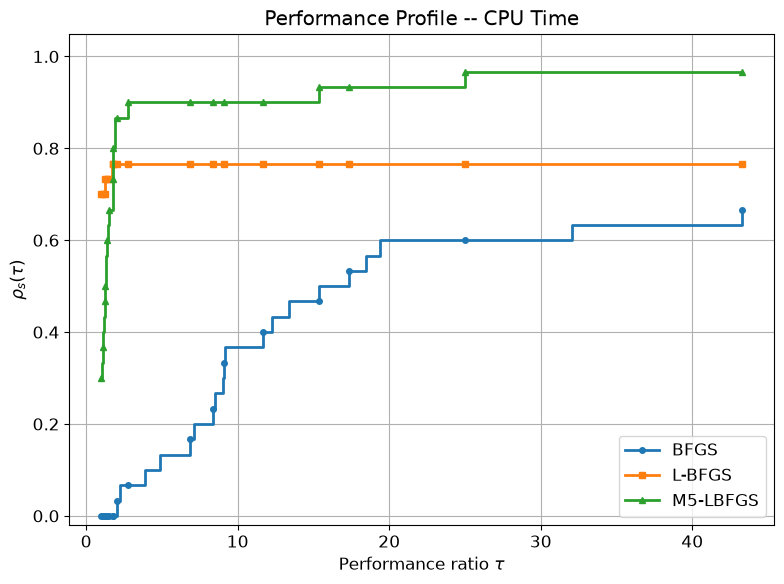

In [18]:
# ============================================================
# Part 17 : Performance Profiles -- Iterations, Grad. evals, CPU time
# ============================================================

method_names = [m for m, _ in METHODS]

profiles_iter = dolan_more_profile(master_df, "Iter.", method_names)
plot_performance_profile(profiles_iter, "Performance Profile -- Outer Iterations")

profiles_grad = dolan_more_profile(master_df, "Grad. evals", method_names)
plot_performance_profile(profiles_grad, "Performance Profile -- Gradient Evaluations")

profiles_cpu = dolan_more_profile(master_df, "CPU (s)", method_names)
plot_performance_profile(profiles_cpu, "Performance Profile -- CPU Time")
